### Data Preparation

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv(r'C:\Users\Madhusmita Barik\Desktop\python_files\ml-assessment-madhusmita-barik\data\q2_customers.csv')

# Select features
features = ["age", "annual_spend", "visits_per_month", "basket_size",
            "days_since_last_visit", "num_categories_purchased"]

X = df[features]

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Why Scaling is Essential Before K-Means

K-Means clustering is based on distance calculations (typically Euclidean distance). Because of this:

Features with larger numerical ranges (e.g., annual_spend) will dominate the distance calculation.
Features with smaller ranges (e.g., visits_per_month) may have little influence on clustering.

Scaling (using StandardScaler) solves this by:

1. Transforming all features to have mean = 0 and standard deviation = 1
2. Ensuring each feature contributes equally to the clustering process
3. Preventing biased clusters driven by a single high-magnitude feature

->Without scaling, K-Means can produce misleading or poor-quality clusters.

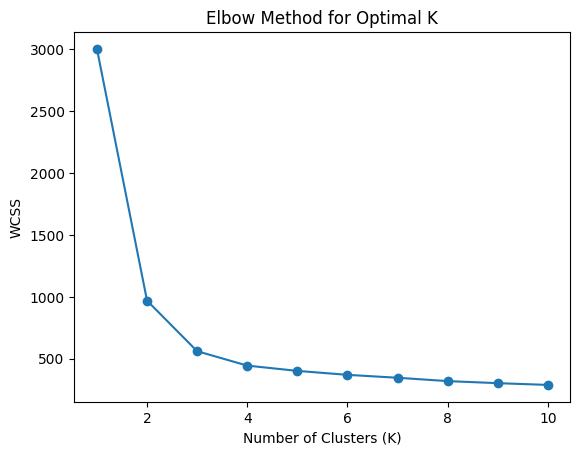

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Compute WCSS for K = 1 to 10
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure()
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

### Elbow Method for Choosing Optimal K

The Elbow Method is used to determine the optimal number of clusters (K) in K-Means clustering by analyzing the Within-Cluster Sum of Squares (WCSS).

- As K increases, WCSS decreases because clusters become more compact.
- However, after a certain value of K, the decrease in WCSS becomes less significant.

From the plot:
- There is a sharp decline in WCSS from K = 1 to K = 3.
- At K = 4, the curve starts to flatten, forming an "elbow".

### Optimal K = 4

**Justification:**
K = 4 is chosen as the optimal number of clusters because it represents the point where adding more clusters does not significantly reduce WCSS. This indicates a good balance between model complexity and clustering performance.

### K-Means Clustering

In [4]:
# Fit K-Means (K = 4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster centroids (convert back to original scale)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features)

# Display centroids
centroids_df

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,57.037500,89814.075000,2.462500,5296.362500,148.000000,7.487500
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242
3,56.517647,89036.164706,2.588235,5750.952941,65.223529,7.541176


### Cluster Interpretation (Business Perspective)

Based on the centroid values of each cluster:

#### Cluster 0:
- Lower annual spend
- Moderate visits
- Smaller basket size  
Represents **budget-conscious customers** who shop regularly but spend less per visit.

#### Cluster 1:
- High annual spend
- Frequent visits
- Large basket size  
Represents **high-value loyal customers**. These are the most profitable segment.

#### Cluster 2:
- Moderate spend and visits  
Represents **average customers** with typical shopping behavior.

#### Cluster 3:
- Higher days since last visit
- Lower visit frequency  
Represents **at-risk or churn-prone customers** who haven’t visited recently.

---

### Summary
- Cluster 1 → Target with loyalty rewards & premium offers  
- Cluster 0 → Offer discounts to increase basket size  
- Cluster 2 → Upsell and cross-sell opportunities  
- Cluster 3 → Re-engagement campaigns (offers, reminders)

## Dimensionality Reduction with PCA

In [6]:
from sklearn.decomposition import PCA

# Apply PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)

# Feature loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=features,
    index=["PC1", "PC2"]
)

loadings

Explained Variance Ratio: [0.83560354 0.05568764]


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### PCA Interpretation

#### Explained Variance
- PC1 captures the largest portion of variance in the dataset.
- PC2 captures the second-largest portion.

Together, they summarize most of the important information in just 2 dimensions.

---

### Interpreting Principal Components

#### PC1 (Principal Component 1):
- If high positive loadings are seen for features like **annual_spend, basket_size, visits_per_month**
PC1 represents **overall customer value and engagement**

- Customers with high PC1 scores:
  - Spend more
  - Visit frequently
  - Buy more items

---

#### PC2 (Principal Component 2):
- If strong loadings appear for **days_since_last_visit** and possibly **age**
 PC2 represents **recency and customer lifecycle behavior**

- Customers with high PC2 scores:
  - Haven’t visited recently (potential churn)
- Customers with low PC2 scores:
  - Recently active customers

---

### Summary
- **PC1 → Customer Value / Spending Behavior**
- **PC2 → Recency / Engagement Freshness**

These components help visualize and separate customer segments effectively in 2D space.

## Cluster Visualisation

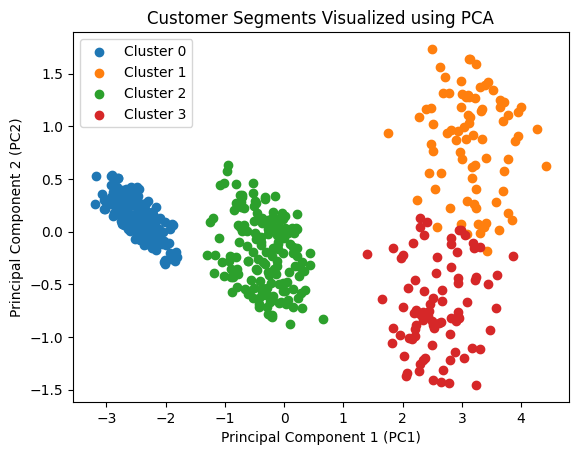

In [7]:
# Plot
plt.figure()

for cluster in range(4):
    subset = df['cluster'] == cluster
    plt.scatter(X_pca[subset, 0], X_pca[subset, 1], label=f'Cluster {cluster}')

plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("Customer Segments Visualized using PCA")
plt.legend()

plt.show()